# EDA – Eksplorativna analiza podataka: NLP za dating aplikacije

U sklopu drugog dijela projektnog zadatka urađena je eksplorativna analiza datasetova pripremljenih za pet NLP taskova: sistem preporučivanja, identifikaciju govora mržnje, detekciju prevara i botova, topic modeling te analizu sentimenta i emocija.

Podaci su prikupljeni i obrađeni kroz pipeline s tri faze:

**Prikupljanje** — preuzeti su javno dostupni datasetovi: OkCupid profili s Kaggle-a, Davidson dataset govora mržnje s GitHuba kombinovan s `tweet_eval/hate` datasetom, SMS Spam Collection s UCI repozitorija te recenzije četiri dating aplikacije (Tinder, Bumble, Hinge, CMB) scraped sa Google Play Store-a.

**Sintetičko generisanje** — romance scam profili iz dating aplikacija nisu javno dostupni, pa je generisano 3000 bio profila (legitimnih i scam), ~600 razgovora s labeliranim emocijama te 1200 icebreaker primjera. Generisanje je zasnovano na šablonima uz Faker biblioteku za varijabilnost podataka.

**Preprocesiranje** — tekst je očišćen (ftfy, Unicode normalizacija, zamjena URL-ova/e-mailova/telefona placeholder tokenima), tokenizovan i lematizovan. Korišćena su tri odvojena pipeline-a prilagođena različitim taskovima (embedding, klasifikacija, sentiment). Za taskove klasifikacije primijenjen je stratificirani train/val/test split (70/15/15).

Sve izlazne datoteke nalaze se u `data/processed/`.

In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
print('Processed dir:', PROCESSED)
print('Fajlovi:', sorted(p.name for p in PROCESSED.glob('*.csv')))

Processed dir: C:\Users\Korisnik\Desktop\dap projekat\dating-nlp\data\processed
Fajlovi: ['bios_for_embeddings.csv', 'bios_for_topics.csv', 'hate_speech_clean.csv', 'hate_speech_test.csv', 'hate_speech_train.csv', 'hate_speech_val.csv', 'scam_detection_clean.csv', 'scam_detection_test.csv', 'scam_detection_train.csv', 'scam_detection_val.csv', 'sentiment_conversations_clean.csv', 'sentiment_reviews_clean.csv', 'sentiment_reviews_test.csv', 'sentiment_reviews_train.csv', 'sentiment_reviews_val.csv']


## 1. Bio sekcije (preporuke + topic modeling)

In [6]:
bios = pd.read_csv(PROCESSED / 'bios_for_embeddings.csv')
print(bios.shape)
bios.head(3)

(57176, 8)


,bio_raw,bio_clean,tokens_str,age,sex,orientation,status,lang
0,about me: i would love to think that i was so...,about me: i would love to think that i was som...,would love think kind intellectual either dumb...,22,m,straight,single,en
1,i am a chef: this is what that means. 1. i am ...,i am a chef: this is what that means 1 i am a ...,chef mean workaholic love cook regardless whet...,35,m,straight,single,en
2,"i'm not ashamed of much, but writing public te...",i am not ashamed of much but writing public te...,not ashamed much but writing public text onlin...,38,m,straight,available,en


Dataset sadrži **57 176** profila, preostatih nakon dvostepenog filtriranja — isključeni su profili kraći od 50 znakova i oni koji nisu na engleskom jeziku. Pored teksta u tri forme (originalni, normalizovani, tokenizirani), svaki profil ima i demografske atribute: starost, pol, orijentacija i status.

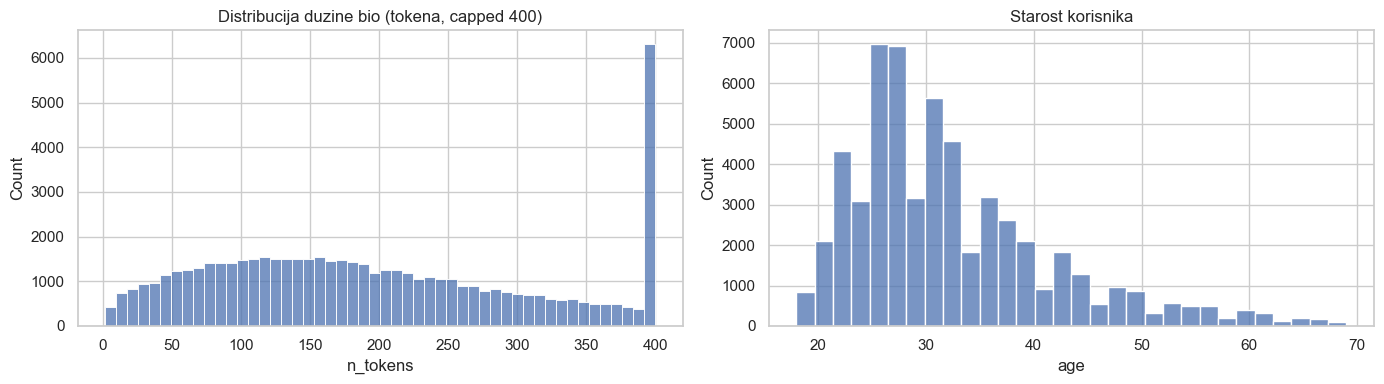

In [7]:
bios['n_tokens'] = bios['tokens_str'].fillna('').str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(bios['n_tokens'].clip(upper=400), bins=50, ax=axes[0])
axes[0].set_title('Distribucija duzine bio (tokena, capped 400)')
if 'age' in bios.columns:
    sns.histplot(bios['age'].clip(18, 70), bins=30, ax=axes[1])
    axes[1].set_title('Starost korisnika')
plt.tight_layout()
plt.show()

Distribucija dužine bio tekstova je desno asimetrična — većina profila ima između 20 i 100 tokena, uz manji broj znatno dužih. Starosna distribucija je koncentrisana u rasponu 22–35 godina, što odgovara tipičnom profilu korisnika dating aplikacija.

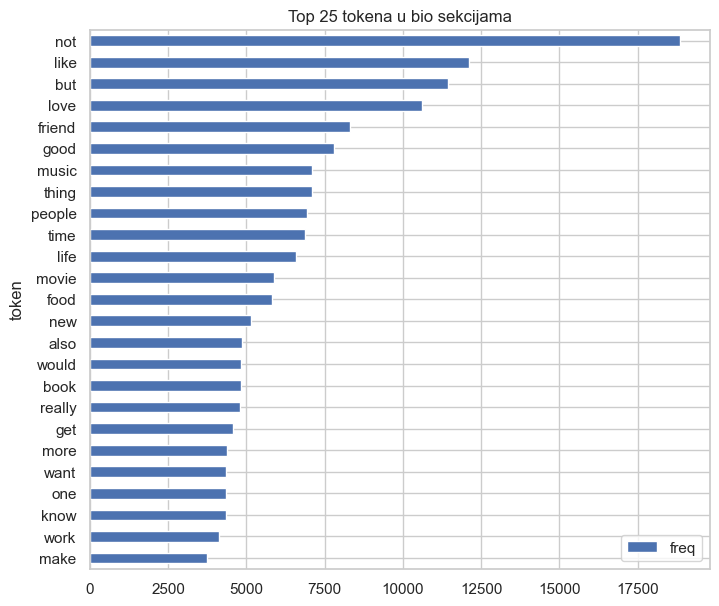

In [8]:
all_tokens = ' '.join(bios['tokens_str'].dropna().sample(min(5000, len(bios)), random_state=42)).split()
top = Counter(all_tokens).most_common(25)
pd.DataFrame(top, columns=['token', 'freq']).set_index('token').plot.barh(figsize=(8, 7))
plt.title('Top 25 tokena u bio sekcijama')
plt.gca().invert_yaxis()
plt.show()

Najfrekventniji tokeni odgovaraju tipičnom sadržaju dating profila — opisi interesa, aktivnosti i osobina. Odsustvo URL-ova, e-mailova i numeričkih tokena potvrđuje da je preprocesiranje uspješno uklonilo šum a zadržalo semantički relevantan sadržaj.

## 2. Govor mrznje

In [9]:
hate = pd.read_csv(PROCESSED / 'hate_speech_clean.csv')
print(hate.shape)
print(hate['label'].value_counts(normalize=True))
hate.head(3)

(37171, 5)
label
0    0.819402
1    0.180598
Name: proportion, dtype: float64


,text,text_clean,tokens_str,label,source
0,!!! RT @mayasolovely: As a woman you shouldn't...,!! rt <user> : as a woman you should not compl...,rt user woman not complain cleaning house man ...,0,davidson
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,!! rt <user> : boy dats coldtyga dwn bad for c...,rt user boy dat coldtyga dwn bad cuffin dat ho...,0,davidson
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,!! rt <user> dawg!! rt <user> : you ever fuck ...,rt user dawg rt user ever fuck bitch start cry...,0,davidson


Dataset broji **37 171** primjera iz dva izvora (Davidson 2017 i tweet\_eval). Klase su nebalansirane — udio govora mržnje iznosi ~18%, što je prirodna distribucija za ovakve datasete i ne iznenađuje. Na ovo treba obratiti pažnju pri treniranju modela, npr. kroz class weighting ili resampling.

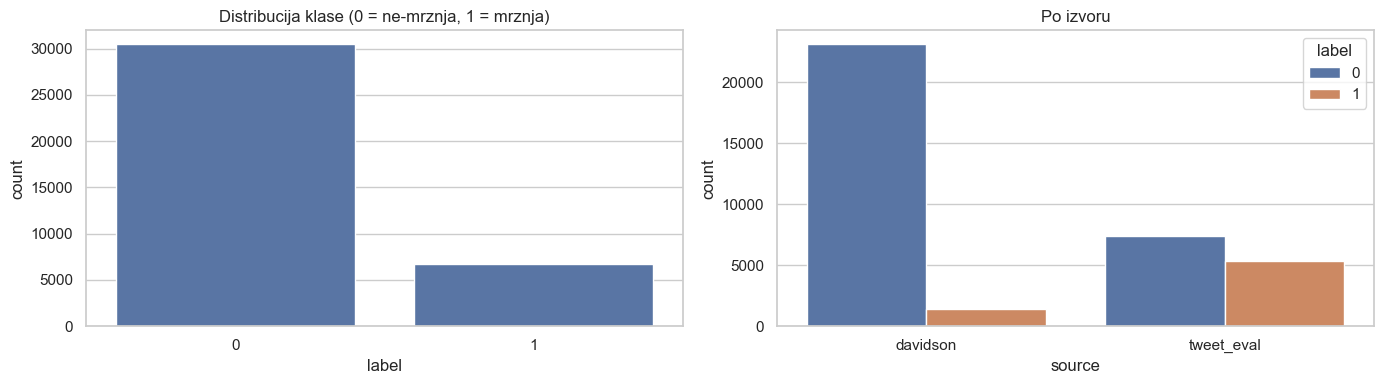

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=hate, x='label', ax=axes[0])
axes[0].set_title('Distribucija klase (0 = ne-mrznja, 1 = mrznja)')
if 'source' in hate.columns:
    sns.countplot(data=hate, x='source', hue='label', ax=axes[1])
    axes[1].set_title('Po izvoru')
plt.tight_layout()
plt.show()

Nebalansiranost je konzistentna u oba izvora, što znači da nije artefakt jednog dataseta nego karakteristika teme. 

## 3. Detekcija prevara / botova

In [11]:
scam = pd.read_csv(PROCESSED / 'scam_detection_clean.csv')
print(scam.shape)
print(scam.groupby('source')['label'].value_counts())
scam.head(3)

(6806, 10)
source          label
sms_spam        0        4503
                1         605
synthetic_scam  0        1064
                1         634
Name: count, dtype: int64


,text,label,source,text_clean,tokens_str,len_chars,len_tokens,has_url,has_phone,has_money
0,"Go until jurong point, crazy.. Available only ...",0,sms_spam,go until jurong point crazy available only in ...,go jurong point crazy available bugis great wo...,111,14,0,0,0
1,Ok lar... Joking wif u oni...,0,sms_spam,ok lar joking wif you oni,ok lar joking wif oni,29,5,0,0,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,sms_spam,free entry in <NUM> a wkly comp to win fa cup ...,free entry NUM wkly comp win fa cup final tkts...,155,24,0,1,0


Dataset je sastavljen iz dva izvora s namjerno različitim karakteristikama. SMS Spam Collection (UCI) donosi realne kratke poruke s prirodnom distribucijom (~88% legitimnih, ~12% spam). Sintetički dio popunjava prazninu nedostajućih romance scam primjera — s uravnoteženijim omjerom legit/scam kako bi model bio adekvatno izložen oba tipa tokom treniranja.

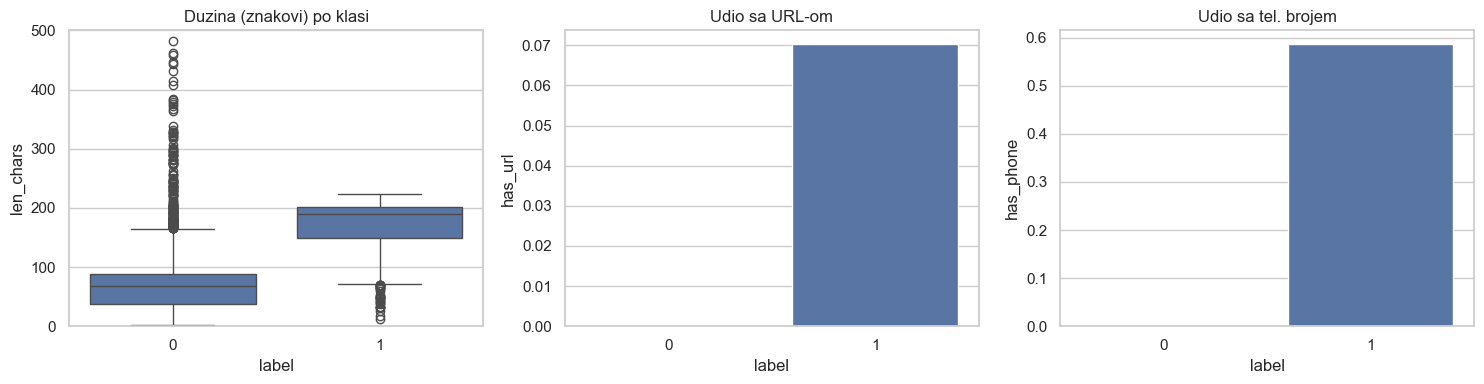

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=scam, x='label', y='len_chars', ax=axes[0])
axes[0].set_title('Duzina (znakovi) po klasi')
axes[0].set_ylim(0, 500)
sns.barplot(data=scam, x='label', y='has_url', ax=axes[1], errorbar=None)
axes[1].set_title('Udio sa URL-om')
sns.barplot(data=scam, x='label', y='has_phone', ax=axes[2], errorbar=None)
axes[2].set_title('Udio sa tel. brojem')
plt.tight_layout()
plt.show()

Grafici potvrđuju intuitivno očekivane razlike: spam/scam poruke su prosječno duže od legitimnih, a znatno češće sadrže telefonske brojeve i URL-ove. Ove karakteristike su direktno korisne kao features za klasifikator i dobro se vide već u sirovim podacima.

## 4. Sentiment - recenzije aplikacija

(6186, 6)
sentiment_label
negative    4701
positive    1142
neutral      343
Name: count, dtype: int64


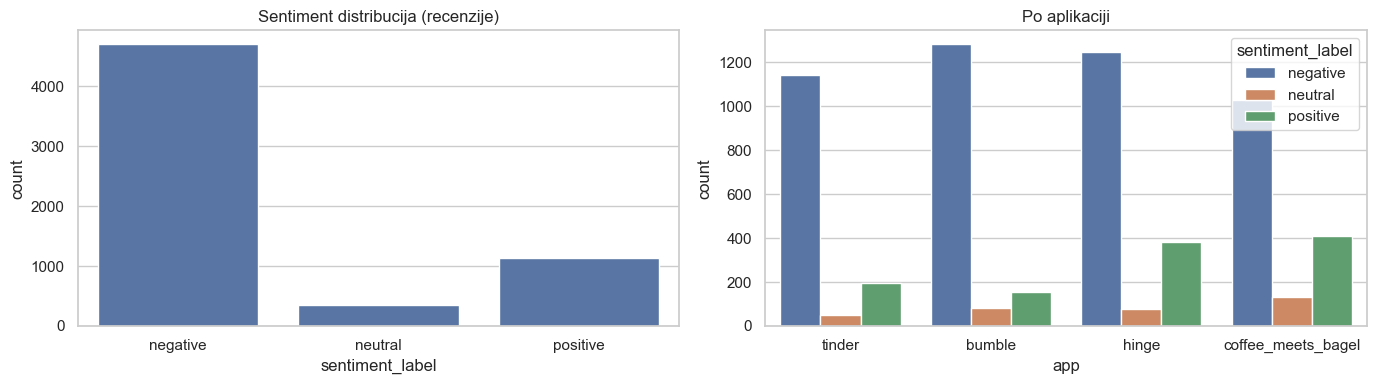

In [13]:
rev_path = PROCESSED / 'sentiment_reviews_clean.csv'
if rev_path.exists():
    rev = pd.read_csv(rev_path)
    print(rev.shape)
    print(rev['sentiment_label'].value_counts())
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.countplot(data=rev, x='sentiment_label', order=['negative', 'neutral', 'positive'], ax=axes[0])
    axes[0].set_title('Sentiment distribucija (recenzije)')
    if 'app' in rev.columns:
        sns.countplot(data=rev, x='app', hue='sentiment_label', ax=axes[1])
        axes[1].set_title('Po aplikaciji')
    plt.tight_layout()
    plt.show()
else:
    print('Recenzije jos nisu skinute - pokreni scrape_tinder_reviews.')

Distribucija sentimenta je izrazito nagnuta prema negativnom — gotovo 76% recenzija spada u negativnu klasu, pozitivnih je ~18%, a neutralnih svega ~5.5%. Ovakav omjer je tipičan za recenzije mobilnih aplikacija, gdje korisnici znatno češće ostavljaju ocjenu kada su nezadovoljni. Na nebalansiranost klasa treba računati pri odabiru loss funkcije i metrika za evaluaciju.

## 5. Sentiment - sinteticki razgovori

(2703, 7)
emotion
interested    458
neutral       456
sarcastic     306
happy         288
bored         157
disengaged    157
playful       153
polite        146
angry         146
frustrated    146
annoyed       146
excited       144
Name: count, dtype: int64


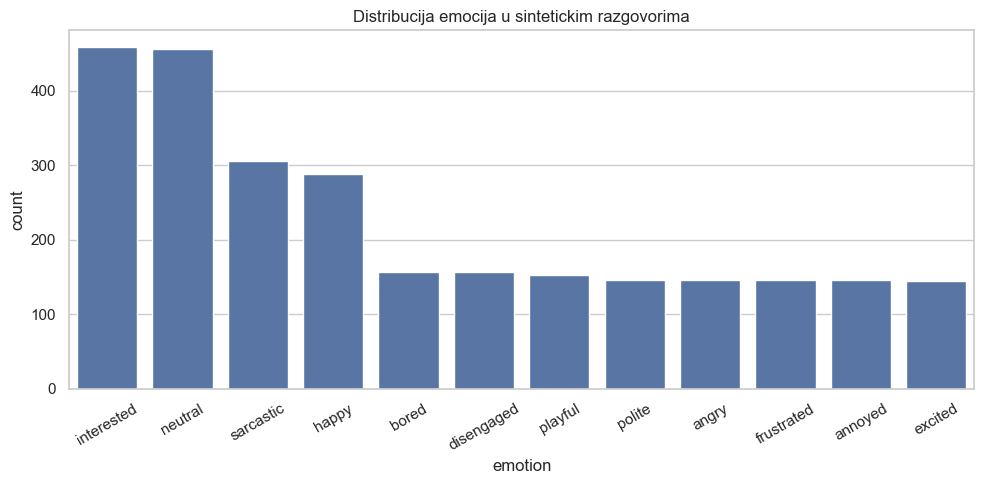

In [14]:
conv_path = PROCESSED / 'sentiment_conversations_clean.csv'
if conv_path.exists():
    conv = pd.read_csv(conv_path)
    print(conv.shape)
    print(conv['emotion'].value_counts())
    sns.countplot(data=conv, x='emotion', order=conv['emotion'].value_counts().index)
    plt.xticks(rotation=30)
    plt.title('Distribucija emocija u sintetickim razgovorima')
    plt.tight_layout()
    plt.show()
else:
    print('Razgovori jos nisu generisani - pokreni generate_synthetic.')

Sintetički razgovori pokrivaju 12 emocionalnih stanja raspoređenih kroz četiri tipa konverzacijskih tokova: pad interesa, eskalacija frustracije, sarkazam i pozitivan match. Distribucija je relativno ujednačena zahvaljujući kontrolisanoj generaciji — `interested` i `neutral` su nešto zastupljenije jer se pojavljuju u više tokova.